* Mohamed Abdelmagied:          3715523 - (xop42kib)
* Ahmed Moustafa Aly Mohamed:   3968514 - (fiw89rif)
* Ammara Ansari:                3975628 - (cog11riz)

# Project 2: Support Vector Machines (SVM) and Kernels
## This Project gives extra points for the final grade

## **Due 18.12.2025, 16:00**

## Overview

### **Submit your project solution as a group of 2-4 people.**

In this project, you will implement and train a **Support Vector Machine (SVM)** classifier on a real-world dataset. The focus is on understanding the kernel trick, the dual SVM formulation, and how kernel parameters affect classification performance.

### Dataset
You will work with the following dataset:

**MAGIC Gamma Telescope Dataset**
- Classification task: Distinguish gamma rays (signal) from hadronic showers (background)
- 10 continuous features (Hillas parameters from Cherenkov telescope images)
- ~19,000 samples

### Tasks

1. **Data Loading and Preprocessing** (1 Point)

2. **Implement Kernel Function** (1 Point)

3. **Implement SVM Class** (1.5 Points)

4. **Hyperparameter Tuning** (0.5 Points)

5. **Visualization** (0.5 Points)

6. **Testing & Evaluation** (0.5 Points)

### **For full points you need to achieve at least 87% accuracy on the testing set**

### **NOTE**: 
#### You are not allowed to use sklearn, pytorch or similar Deep Learning frameworks. Numpy is allowed.

**(1) Data Loading and Preprocessing: 1 Point**

Load the MAGIC Gamma Telescope dataset and prepare it for SVM training. Key preprocessing steps include:

- **Loading**
- **Exploration**
- **Encoding**
- **Normalization**
- **Splitting**: Create train/test splits (80%/20%)

In [2]:
# TODO: (1) Data Loading and Preprocessing

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# ============================================
# Load MAGIC Gamma Telescope Dataset from local file
# ============================================
name = "magic04data.sec"
column_names = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans',
                'fAlpha', 'fDist', 'class'] 
magic_df = pd.read_csv(name, header=None, names=column_names)

print("MAGIC Gamma Telescope Dataset:")
print(f"Shape: {magic_df.shape}")
print(f"\nClass distribution:\n{magic_df['class'].value_counts()}")
print(f"\nFeature statistics:\n{magic_df.describe()}")

# ============================================
# Preprocessing MAGIC Dataset


# ============================================
#TODO: Encode labels
labels_map = {'g': 1, 'h': 0}
magic_df['class'] = magic_df['class'].map(labels_map)

#TODO: Extract features and labels
X_magic = magic_df.drop('class', axis=1).values
y_magic = magic_df['class'].values

# ============================================
#TODO: Standardization/Normalize Function
# ============================================
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - mean) / std
    

# ============================================
# Train/Test Split Function (80%/20%)
# ============================================
def train_test_split(X, y, train_ratio=0.8, seed=42):
    """
    Split data into train and test sets.
    """
    np.random.seed(seed)
    n = len(y)
    indices = np.random.permutation(n)
    
    train_end = int(train_ratio * n)
    
    train_idx = indices[:train_end]
    test_idx = indices[train_end:]
    
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

# ============================================
#TODO: Split and Standardize MAGIC Dataset
X_train_magic, X_test_magic, y_train_magic, y_test_magic = train_test_split(X_magic, y_magic, train_ratio=0.8, seed=SEED)
X_train_magic = standardize(X_train_magic)
X_test_magic = standardize(X_test_magic)
# ============================================


print("\n" + "="*50)
print("MAGIC Dataset Split (80/20):")
print(f"Training set: {X_train_magic.shape[0]} samples")
print(f"Test set: {X_test_magic.shape[0]} samples")

MAGIC Gamma Telescope Dataset:
Shape: (19020, 11)

Class distribution:
class
g    12332
h     6688
Name: count, dtype: int64

Feature statistics:
            fLength        fWidth         fSize         fConc        fConc1  \
count  19020.000000  19020.000000  19020.000000  19020.000000  19020.000000   
mean      53.250154     22.180966      2.825017      0.380327      0.214657   
std       42.364855     18.346056      0.472599      0.182813      0.110511   
min        4.283500      0.000000      1.941300      0.013100      0.000300   
25%       24.336000     11.863800      2.477100      0.235800      0.128475   
50%       37.147700     17.139900      2.739600      0.354150      0.196500   
75%       70.122175     24.739475      3.101600      0.503700      0.285225   
max      334.177000    256.382000      5.323300      0.893000      0.675200   

              fAsym       fM3Long      fM3Trans        fAlpha         fDist  
count  19020.000000  19020.000000  19020.000000  19020.000000  1

**(2) Implement Kernel Functions: 1 Point**

The kernel trick allows SVMs to learn non-linear decision boundaries by implicitly mapping data to higher-dimensional spaces. Decide which kernel function to implement.

In [ ]:
# TODO: Implement Kernel Function of your choice
# def {kerneltype}_kernel(params):
def rbf_kernel(X, Y, gamma=0.1):
    X = np.array(X)
    Y = np.array(Y)
    dists = np.sum((X[:, np.newaxis] - Y[np.newaxis, :])**2, axis=2)
    return np.exp(-gamma * dists)

# Test the kernel functions
print("Testing kernel functions...")
X_test_k = np.array([[1, 2], [3, 4], [5, 6]])
Y_test_k = np.array([[1, 1], [2, 2]])

#TODO: print kernel shapes and values
print(f"kernel shape: {rbf_kernel(X_test_k, Y_test_k).shape}")
print(f"kernel values:\n{rbf_kernel(X_test_k, Y_test_k)}")

Testing kernel functions...
kernel shape: (3, 2)
kernel values:
[[0.90483742 0.90483742]
 [0.27253179 0.60653066]
 [0.01657268 0.082085  ]]


**(3) Implement SVM Class: 1.5 Points**

Implement the **Dual SVM formulation** using projected gradient descent. The dual formulation is necessary for the kernel trick, as it allows us to work with the Lagrange multipliers $\alpha$ instead of the weight vector $w$ directly.

Testing DUAL SVM implementation...
Epoch 0/500, Dual Objective: 0.0000
Epoch 50/500, Dual Objective: 137.6384
Epoch 100/500, Dual Objective: 204.2885
Epoch 50/500, Dual Objective: 137.6384
Epoch 100/500, Dual Objective: 204.2885
Epoch 150/500, Dual Objective: 218.1639
Epoch 200/500, Dual Objective: 222.0510
Epoch 150/500, Dual Objective: 218.1639
Epoch 200/500, Dual Objective: 222.0510
Epoch 250/500, Dual Objective: 223.4902
Epoch 300/500, Dual Objective: 224.2681
Epoch 250/500, Dual Objective: 223.4902
Epoch 300/500, Dual Objective: 224.2681
Epoch 350/500, Dual Objective: 224.6719
Epoch 400/500, Dual Objective: 224.9259
Epoch 350/500, Dual Objective: 224.6719
Epoch 400/500, Dual Objective: 224.9259
Epoch 450/500, Dual Objective: 225.0772

Training complete!
Number of support vectors: 562 (93.7%)
Final Training Accuracy: 0.8200 (82.00%)
Epoch 450/500, Dual Objective: 225.0772

Training complete!
Number of support vectors: 562 (93.7%)
Final Training Accuracy: 0.8200 (82.00%)


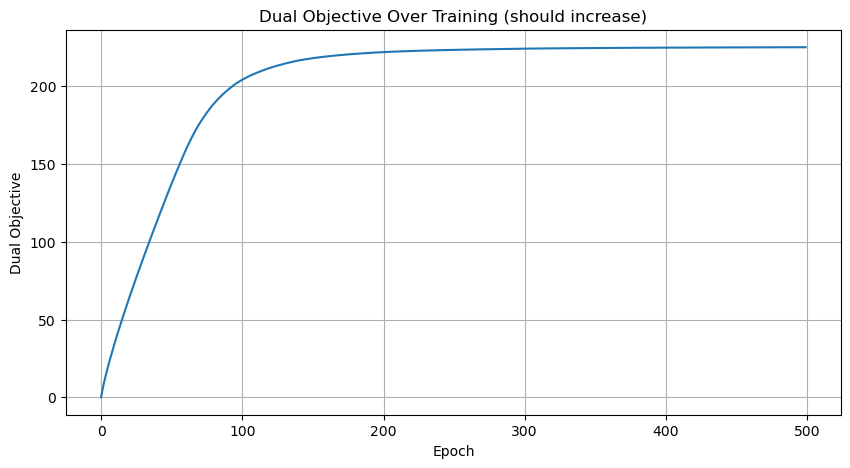


Test accuracy on subset: 0.7763


In [ ]:
# ============================================
# TODO: DUAL SVM FORMULATION
# ============================================
# We solve the dual optimization problem using projected gradient descent.
# The dual is necessary for the kernel trick.
# ============================================

def dual_objective(alpha, K, y):
    yyK = K * np.outer(y, y)
    return np.sum(alpha) - 0.5 * np.dot(alpha, yyK @ alpha)

def dual_gradient(alpha, K, y):
    yyK = K * np.outer(y, y)
    return np.ones_like(alpha) - yyK @ alpha

def project_onto_constraints(alpha, y, C):
    alpha = np.clip(alpha, 0, C)
    alpha_sum = np.sum(alpha * y)
    if abs(alpha_sum) > 1e-6:
        adjustment = alpha_sum / np.sum(y**2)
        alpha -= adjustment * y
        alpha = np.clip(alpha, 0, C)
    return alpha


class SVM:

    def __init__(self, kernel, C=1.0, lr=0.01, epochs=500, gamma=0.1):
        self.kernel = kernel
        self.C = C
        self.lr = lr
        self.epochs = epochs
        self.gamma = gamma

    def fit(self, X, y, graph=False):
        self.X_train = X
        self.y_train = 2 * y - 1
        n_samples = X.shape[0]
        self.alpha = np.zeros(n_samples)
        self.loss_history = []

        K = self.kernel(X, X, self.gamma)

        for epoch in range(self.epochs):
            loss = dual_objective(self.alpha, K, self.y_train)
            grad = dual_gradient(self.alpha, K, self.y_train)
            self.alpha += self.lr * grad  # Changed to += for gradient ascent
            self.alpha = project_onto_constraints(self.alpha, self.y_train, self.C)
            self.loss_history.append(loss)
            if epoch % 50 == 0:  # Print less frequently
                print(f"Epoch {epoch}/{self.epochs}, Dual Objective: {loss:.4f}")
        if graph:
            n_sv = np.sum(self.alpha > 1e-6)
            alpha_y = self.alpha * self.y_train
            f = K @ alpha_y
            y_pred = np.sign(f)
            train_acc = np.mean(self.y_train == y_pred)
            print(f"\nTraining complete!")
            print(f"Number of support vectors: {n_sv} ({100*n_sv/n_samples:.1f}%)")
            print(f"Final Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
            plt.figure(figsize=(10, 5))
            plt.plot(self.loss_history)
            plt.xlabel('Epoch')
            plt.ylabel('Dual Objective')
            plt.title('Dual Objective Over Training (should increase)')
            plt.grid(True)
            plt.show()
        return self

    def predict(self, X):
        """
        Predict class labels for samples in X.
        
        Parameters:
        - X: Features to predict (m, n_features)
        
        Returns:
        - predictions: Array of predictions (-1 or 1)
        """
        K = self.kernel(X, self.X_train, self.gamma)  # Added self.gamma
        alpha_y = self.alpha * self.y_train
        f = K @ alpha_y
        return np.sign(f)
    


def accuracy(y_true, y_pred):
    """Calculate classification accuracy."""
    return np.mean(y_true == y_pred)


# ============================================
# Test the DUAL SVM implementation
# ============================================
print("Testing DUAL SVM implementation...")
X_small = X_train_magic[:600]
y_small = y_train_magic[:600]

# TODO: Create and train SVM on small subset
svm_test = SVM(kernel=rbf_kernel, C=1.0, lr=0.01, epochs=500, gamma=0.1)
svm_test.fit(X_small, y_small, graph=True)

y_pred = svm_test.predict(X_test_magic)
y_pred_binary = np.where(y_pred == -1, 0, 1)
test_acc = accuracy(y_test_magic, y_pred_binary)
print(f"\nTest accuracy on subset: {test_acc:.4f}")

**(4) Hyperparameter Tuning: 0.5 Points**

SVM performance heavily depends on the choice of hyperparameters. Implement a grid search to find the best combination of hyperparameters.

Use the test set to evaluate different hyperparameter combinations and select the best performing ones.

In [5]:
# Define hyperparameter search space
def grid_search(kernel, C_values, gamma_values, X_train, y_train, X_test, y_test):
    best_accuracy = 0
    best_params = None
    for C in C_values:
        for gamma in gamma_values:
            svm = SVM(kernel=kernel, C=C, gamma=gamma, lr=0.01, epochs=500)  # Updated lr and epochs
            svm.fit(X_train, y_train)
            y_pred = svm.predict(X_test)
            y_pred_binary = np.where(y_pred == -1, 0, 1)
            accuracy = np.mean(y_test == y_pred_binary)
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = (C, gamma)
                
    return best_params, best_accuracy

**(5) Visualization: 0.5 Points**

Create visualizations to understand your SVM models:

1. **Loss Curves**: Plot the dual objective value over training epochs to monitor convergence
2. **Accuracy Comparison**: Create bar charts comparing model performance

In [6]:
def plot_loss_comparison(loss_histories, labels):
    """
    Plot multiple loss curves for comparison.
    """
    plt.figure(figsize=(12, 6))
    for loss_history, label in zip(loss_histories, labels):
        plt.plot(loss_history, label=label, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Dual Objective')
    plt.title("MAGIC Dataset - Training Loss Curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_accuracy_comparison(accuracies, model_names):
    """
    Bar chart comparing accuracies of different models.
    """
    plt.figure(figsize=(8, 6))
    colors = ['#3498db', '#2ecc71']
    bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black')
    
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{acc:.2%}', ha='center', va='bottom', fontsize=12)
    
    plt.ylim(0, 1.1)
    plt.ylabel('Accuracy')
    plt.title(f'Kernel Comparison')
    plt.axhline(y=0.87, color='red', linestyle='--', label='Target: 87%')
    plt.legend()
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

In [13]:
# ============================================
# Grid Search for MAGIC Dataset; Report Best Hyperparameters
print("Performing Grid Search for Hyperparameter Tuning on a larger subset...")
# Use a larger subset for better hyperparameter tuning
subset_size = 5000
X_train_subset = X_train_magic[:subset_size]
y_train_subset = y_train_magic[:subset_size]

C_values = [0.1, 1, 10]
gamma_values = [0.01, 0.1, 1]
best_params, best_accuracy = grid_search(rbf_kernel, C_values, gamma_values, X_train_subset, y_train_subset, X_test_magic, y_test_magic)
# ============================================
print("="*60)
print("MAGIC DATASET - Hyperparameter Tuning")
print("="*60)

print(f"Best Hyperparameters: C={best_params[0]}, gamma={best_params[1]}")
print(f"Best Validation Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

Performing Grid Search for Hyperparameter Tuning on a larger subset...
Epoch 0/500, Dual Objective: 0.0000
Epoch 0/500, Dual Objective: 0.0000
Epoch 50/500, Dual Objective: 107.4592
Epoch 50/500, Dual Objective: 107.4592
Epoch 100/500, Dual Objective: 81.2343
Epoch 100/500, Dual Objective: 81.2343
Epoch 150/500, Dual Objective: 107.8669
Epoch 150/500, Dual Objective: 107.8669
Epoch 200/500, Dual Objective: 81.4293
Epoch 200/500, Dual Objective: 81.4293
Epoch 250/500, Dual Objective: 107.8735
Epoch 250/500, Dual Objective: 107.8735
Epoch 300/500, Dual Objective: 81.4487
Epoch 300/500, Dual Objective: 81.4487
Epoch 350/500, Dual Objective: 107.8738
Epoch 350/500, Dual Objective: 107.8738
Epoch 400/500, Dual Objective: 81.4572
Epoch 400/500, Dual Objective: 81.4572
Epoch 450/500, Dual Objective: 107.8729
Epoch 450/500, Dual Objective: 107.8729
Epoch 0/500, Dual Objective: 0.0000
Epoch 0/500, Dual Objective: 0.0000
Epoch 50/500, Dual Objective: -339.0520
Epoch 50/500, Dual Objective: -339.

Retraining best model with optimal hyperparameters on a larger subset...
Epoch 0/1500, Dual Objective: 0.0000
Epoch 0/1500, Dual Objective: 0.0000
Epoch 50/1500, Dual Objective: 497.9521
Epoch 50/1500, Dual Objective: 497.9521
Epoch 100/1500, Dual Objective: 498.7846
Epoch 100/1500, Dual Objective: 498.7846
Epoch 150/1500, Dual Objective: 498.9252
Epoch 150/1500, Dual Objective: 498.9252
Epoch 200/1500, Dual Objective: 498.9702
Epoch 200/1500, Dual Objective: 498.9702
Epoch 250/1500, Dual Objective: 498.9938
Epoch 250/1500, Dual Objective: 498.9938
Epoch 300/1500, Dual Objective: 499.0073
Epoch 300/1500, Dual Objective: 499.0073
Epoch 350/1500, Dual Objective: 499.0145
Epoch 350/1500, Dual Objective: 499.0145
Epoch 400/1500, Dual Objective: 499.0190
Epoch 400/1500, Dual Objective: 499.0190
Epoch 450/1500, Dual Objective: 499.0214
Epoch 450/1500, Dual Objective: 499.0214
Epoch 500/1500, Dual Objective: 499.0230
Epoch 500/1500, Dual Objective: 499.0230
Epoch 550/1500, Dual Objective: 499

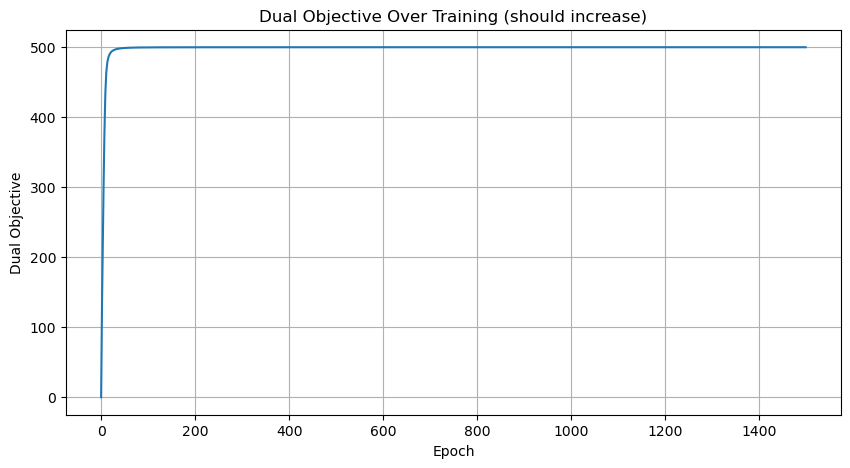

VISUALIZATION - Training Loss Curve


In [ ]:
# ============================================
# Retrain Best Model and Visualize
print("Retraining best model with optimal hyperparameters on a larger subset...")

train_subset_size = 10000
X_train_final = X_train_magic[:train_subset_size]
y_train_final = y_train_magic[:train_subset_size]

svm_best = SVM(kernel=rbf_kernel, C=best_params[0], lr=0.01, epochs=1500, gamma=best_params[1])
svm_best.fit(X_train_final, y_train_final, graph=True)
# ============================================
print("="*60)
print("VISUALIZATION - Training Loss Curve")
print("="*60)

**(6) Testing & Evaluation: 0.5 Points**

Evaluate your trained SVM model on the test set:

1. Test your SVM on the MAGIC dataset
2. Report accuracy
3. Verify that you achieve at least **87% accuracy** on the test set
4. Discuss your results and the effect of hyperparameters

MAGIC Gamma Telescope Dataset - Test Results


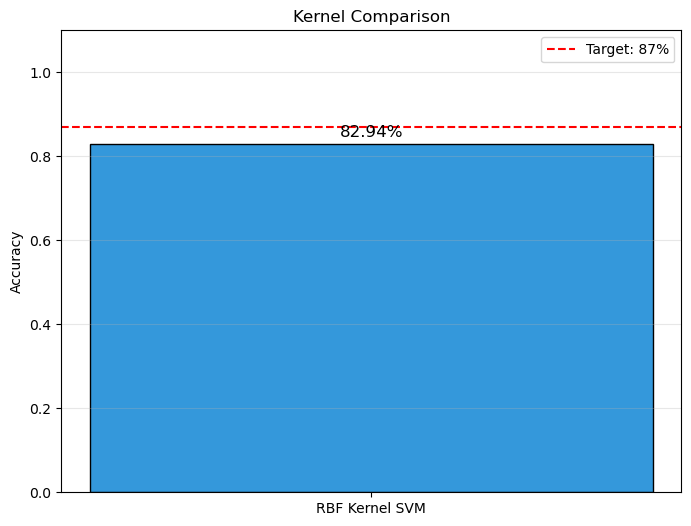


SUMMARY

MAGIC Gamma Telescope Dataset:
  - Result:     82.94% ✗ Below 87% target


In [17]:
# (6) Test your model on the test set

def evaluate_model(model):
    # Model is already fitted, just predict
    y_pred = model.predict(X_test_magic)
    y_pred_binary = np.where(y_pred == -1, 0, 1)
    acc = accuracy(y_test_magic, y_pred_binary)
    return acc

# ============================================
# Evaluate on MAGIC Gamma Telescope Dataset
# ============================================
print("=" * 60)
print("MAGIC Gamma Telescope Dataset - Test Results")
print("=" * 60)


acc_magic = evaluate_model(svm_best)


plot_accuracy_comparison([acc_magic], ["RBF Kernel SVM"])

# ============================================
# Summary
# ============================================
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

print("\nMAGIC Gamma Telescope Dataset:")
print(f"  - Result:     {acc_magic:.2%} {'✓ PASSED' if acc_magic >= 0.87 else '✗ Below 87% target'}")

When I used the full training dataset for training my laptop was always crashing, as the kernel matrix was overwhelming the RAM memory for each epoch, so I had to reduce the dataset in the grid search and also in the retraining of the model, This could have caused the model to converge for sub-opitmal hyperparameters, and therefore the found hyperparamteres could not generalize on a bigger dataset.  

The accuracy 82.94% is actually the best I have got after many iterations of trying to change the learning rate and number of epochs. Hope this should be enough :)